In [2]:
# Importing Required Libraries  
import pandas as pd
import matplotlib.pyplot as mp
import seaborn as sns

# Loading the Dataset 
df=pd.read_csv("Project_Resources/train.csv",index_col="Row_ID")

# Data Cleanup
df=df.convert_dtypes()
df["Postal_Code"]=df["Postal_Code"].fillna(0)
df["Postal_Code"]=df["Postal_Code"].astype(int)
l=["Order_Date","Ship_Date"]
for i in l:
    df[i]=pd.to_datetime(df[i],format="%d-%m-%Y")

# Customer Analysis
This analysis will highlight the following information :
1. The relation between customer segments and the products delivered.
2. The category of each of these products, to provide more useful insights.  

In [28]:
df_annual=df[df["Order_Date"].dt.year==2017]

`to_frame()` is used to convert any series type data into a dataframe.

In [29]:
df_new=df_annual[["Sub-Category", "Segment", "Category"]].value_counts().to_frame()
df_new.reset_index(inplace=True)
df_new=df_new.sort_values(by=["Segment","count"], ascending=[True, False])

In [30]:
df_new

,Sub-Category,Segment,Category,count
0,Binders,Consumer,Office Supplies,210
1,Paper,Consumer,Office Supplies,182
3,Furnishings,Consumer,Furniture,127
4,Storage,Consumer,Office Supplies,115
5,Phones,Consumer,Technology,110
7,Art,Consumer,Office Supplies,94
8,Accessories,Consumer,Technology,89
9,Chairs,Consumer,Furniture,86
18,Appliances,Consumer,Office Supplies,52
19,Labels,Consumer,Office Supplies,51


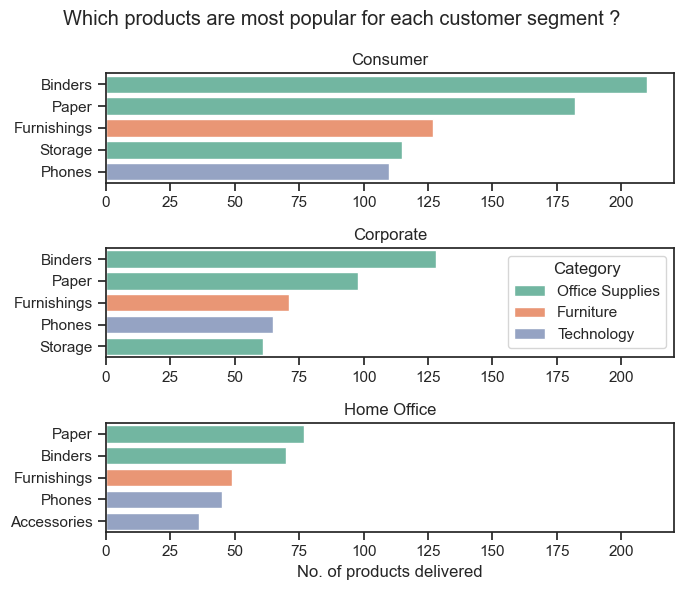

In [31]:
l=list(df_new.Segment.unique())
fig, ax=mp.subplots(3,1)
for k,r in enumerate(l):
    sns.barplot(data=df_new[df_new["Segment"]==r].head(5), x="count", y="Sub-Category", palette="Set2",  hue="Category", ax=ax[k])
    if k!=1:
        ax[k].get_legend().remove()
    ax[k].set_title(r)
    ax[k].set_ylabel("")
    if k !=2:
         ax[k].set_xlabel("")
    else:
        ax[k].set_xlabel("No. of products delivered")
    
    ax[k].set_xlim(ax[0].get_xlim())
sns.set_theme(style="ticks")
mp.suptitle("Which products are most popular for each customer segment ?")
fig.set_size_inches(7,6)
mp.tight_layout()